# 01 — Cohort Overview

Loads `data/processed/cohort.csv` (264 patients, inclusion rules) and
`data/processed/modeling_table.csv` (190 patients after DVH QC).

Produces descriptive statistics and figures for the modeling cohort.

**Figures saved to:** `figures/01_*.png`

In [1]:
import sys
from pathlib import Path

# Allow imports from src/ when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.config import DATA_PROCESSED, FIGURES_DIR

In [2]:
# --- Plot style ---
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = ["#2c7bb6", "#d7191c", "#fdae61", "#1a9641"]

In [3]:
# --- Load data ---
cohort = pd.read_csv(DATA_PROCESSED / "cohort.csv")
modeling = pd.read_csv(DATA_PROCESSED / "modeling_table.csv")

included = cohort[cohort["included"]].copy()
excluded = cohort[~cohort["included"]].copy()

assert len(included) == len(modeling), "cohort included count must match modeling_table"

print(f"Total patients (TSV)     : {len(cohort)}")
print(f"Included (cohort rules)  : {len(included)}")
print(f"Modeling table (DVH QC)  : {len(modeling)}")
print(f"Excluded                 : {len(excluded)}")
print(f"Missing survival         : {included['survival_weeks'].isna().sum()}")

Total patients (TSV)     : 264
Included (cohort rules)  : 190
Modeling table (DVH QC)  : 190
Excluded                 : 74
Missing survival         : 0


## 1. Exclusion Summary

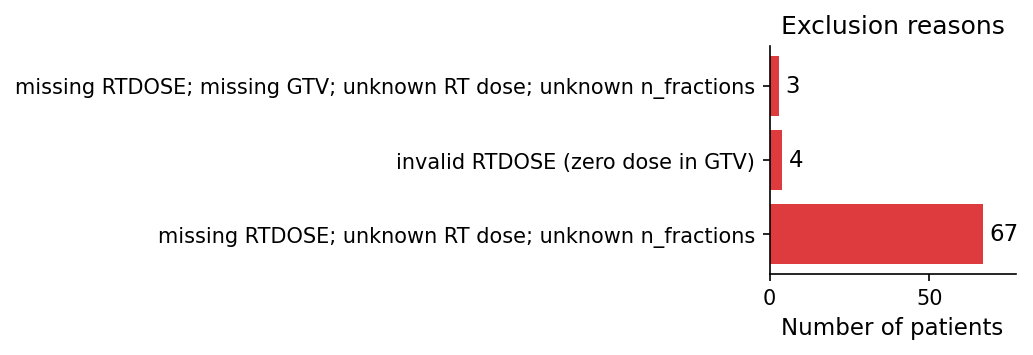

In [4]:
excl_counts = excluded["exclusion_reason"].value_counts()

fig, ax = plt.subplots(figsize=(7, 2.5))
bars = ax.barh(excl_counts.index, excl_counts.values, color=COLORS[1], alpha=0.85)
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of patients")
ax.set_title("Exclusion reasons")
ax.set_xlim(0, excl_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_exclusion_reasons.png")
plt.show()

## 2. Demographics

In [5]:
print("=== Age (years) ===")
print(included["age"].describe().round(1).to_string())
print()
print("=== Sex ===")
print(included["sex"].value_counts().to_string())
print()
print("=== WHO Performance Status ===")
print(included["who_status"].value_counts().sort_index().to_string())

=== Age (years) ===
count    190.0
mean      67.2
std       10.7
min       25.0
25%       60.0
50%       70.0
75%       75.0
max       90.0

=== Sex ===
sex
M    117
F     73

=== WHO Performance Status ===
who_status
0.0     34
1.0    101
2.0     47
3.0      8


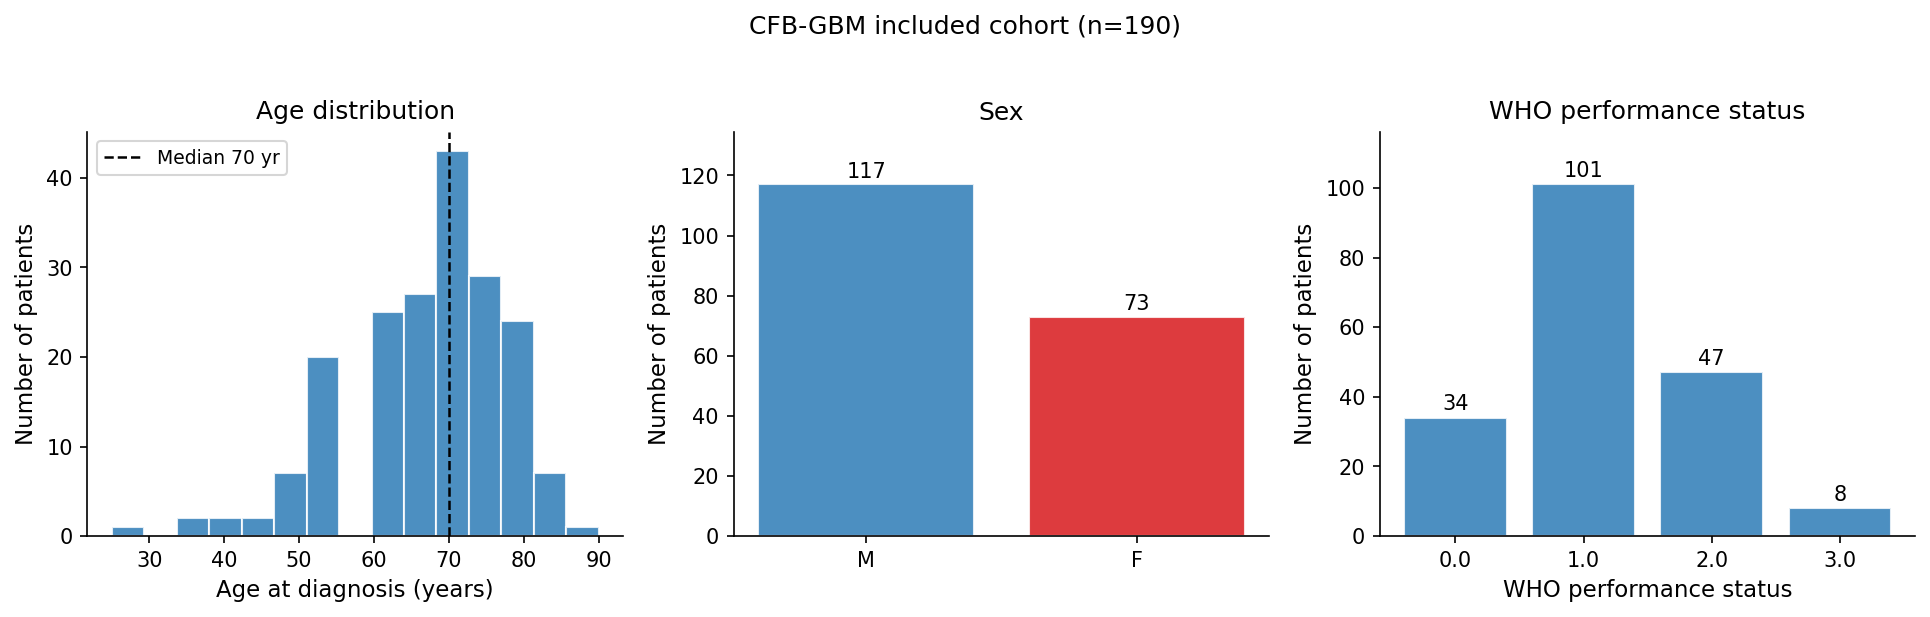

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Age distribution
ax = axes[0]
ax.hist(included["age"].dropna(), bins=15, color=COLORS[0], alpha=0.85, edgecolor="white")
ax.axvline(included["age"].median(), color="black", linestyle="--", linewidth=1.2, label=f"Median {included['age'].median():.0f} yr")
ax.set_xlabel("Age at diagnosis (years)")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution")
ax.legend(fontsize=9)

# Sex
ax = axes[1]
sex_counts = included["sex"].value_counts()
ax.bar(sex_counts.index, sex_counts.values, color=COLORS[:len(sex_counts)], alpha=0.85, edgecolor="white")
for i, (label, val) in enumerate(sex_counts.items()):
    ax.text(i, val + 1, str(val), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of patients")
ax.set_title("Sex")
ax.set_ylim(0, sex_counts.max() * 1.15)

# WHO status
ax = axes[2]
who_counts = included["who_status"].value_counts().sort_index()
ax.bar(who_counts.index.astype(str), who_counts.values, color=COLORS[0], alpha=0.85, edgecolor="white")
for i, val in enumerate(who_counts.values):
    ax.text(i, val + 1, str(val), ha="center", va="bottom", fontsize=10)
ax.set_xlabel("WHO performance status")
ax.set_ylabel("Number of patients")
ax.set_title("WHO performance status")
ax.set_ylim(0, who_counts.max() * 1.15)

plt.suptitle(f"CFB-GBM included cohort (n={len(included)})", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_demographics.png")
plt.show()

## 3. Fractionation Schemes

In [7]:
scheme_counts = included.groupby(["rt_dose_gy", "n_fractions"]).size().reset_index(name="n")
scheme_counts["label"] = scheme_counts.apply(
    lambda r: f"{r['rt_dose_gy']:.2f} Gy / {int(r['n_fractions'])} fr", axis=1
)
scheme_counts = scheme_counts.sort_values("n", ascending=False)
print(scheme_counts[["label", "n"]].to_string(index=False))

           label   n
60.00 Gy / 30 fr 120
40.05 Gy / 15 fr  61
59.40 Gy / 33 fr   4
 25.00 Gy / 5 fr   1
45.00 Gy / 15 fr   1
50.40 Gy / 28 fr   1
52.20 Gy / 29 fr   1
54.00 Gy / 30 fr   1


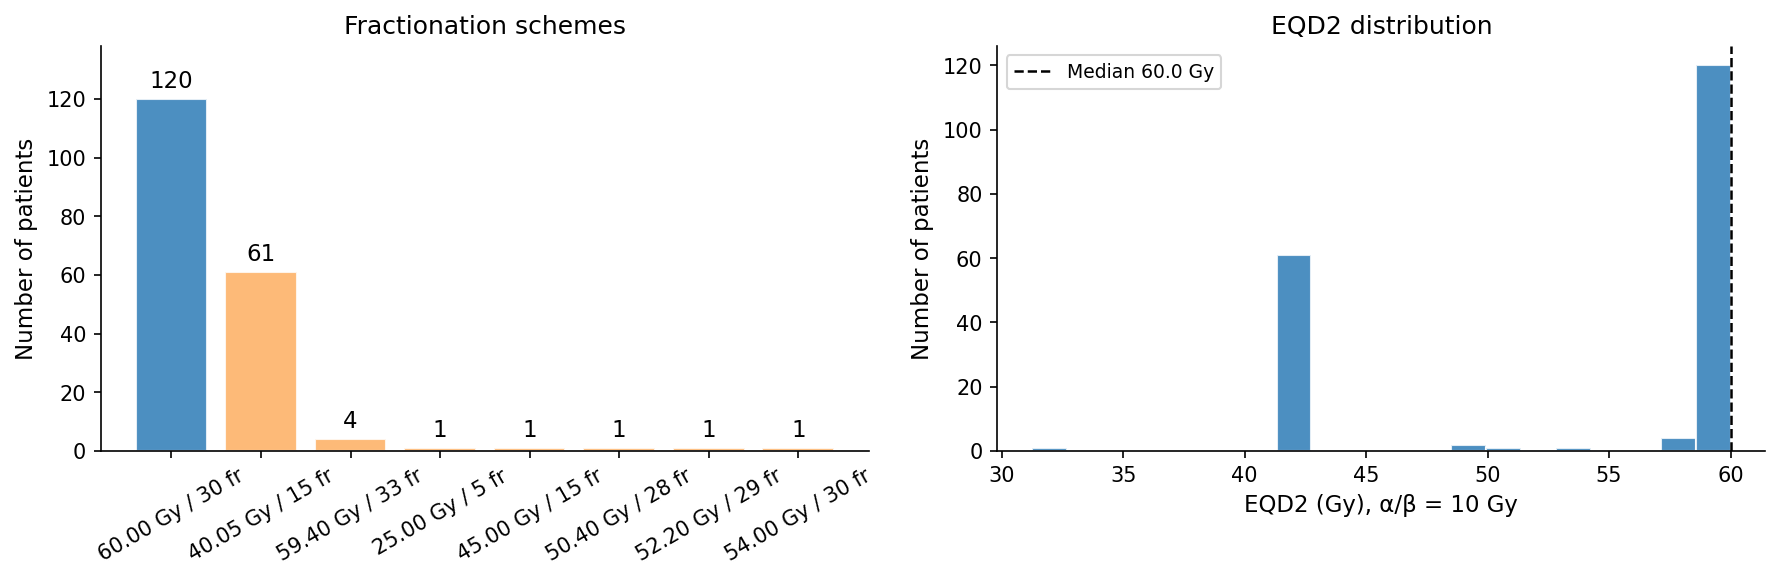

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of fractionation schemes
ax = axes[0]
colors = [COLORS[0] if v == scheme_counts["n"].max() else COLORS[2] for v in scheme_counts["n"]]
bars = ax.bar(scheme_counts["label"], scheme_counts["n"], color=colors, alpha=0.85, edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of patients")
ax.set_title("Fractionation schemes")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, scheme_counts["n"].max() * 1.15)

# EQD2 distribution
ax = axes[1]
ax.hist(included["eqd2_gy"].dropna(), bins=20, color=COLORS[0], alpha=0.85, edgecolor="white")
ax.axvline(included["eqd2_gy"].median(), color="black", linestyle="--", linewidth=1.2,
           label=f"Median {included['eqd2_gy'].median():.1f} Gy")
ax.set_xlabel("EQD2 (Gy), α/β = 10 Gy")
ax.set_ylabel("Number of patients")
ax.set_title("EQD2 distribution")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_fractionation.png")
plt.show()

## 4. Survival Distribution

In [9]:
print("=== Overall Survival (weeks) ===")
print(included["survival_weeks"].describe().round(1).to_string())

=== Overall Survival (weeks) ===
count    190.0
mean      57.5
std       40.7
min        6.0
25%       25.2
50%       51.0
75%       72.8
max      233.0


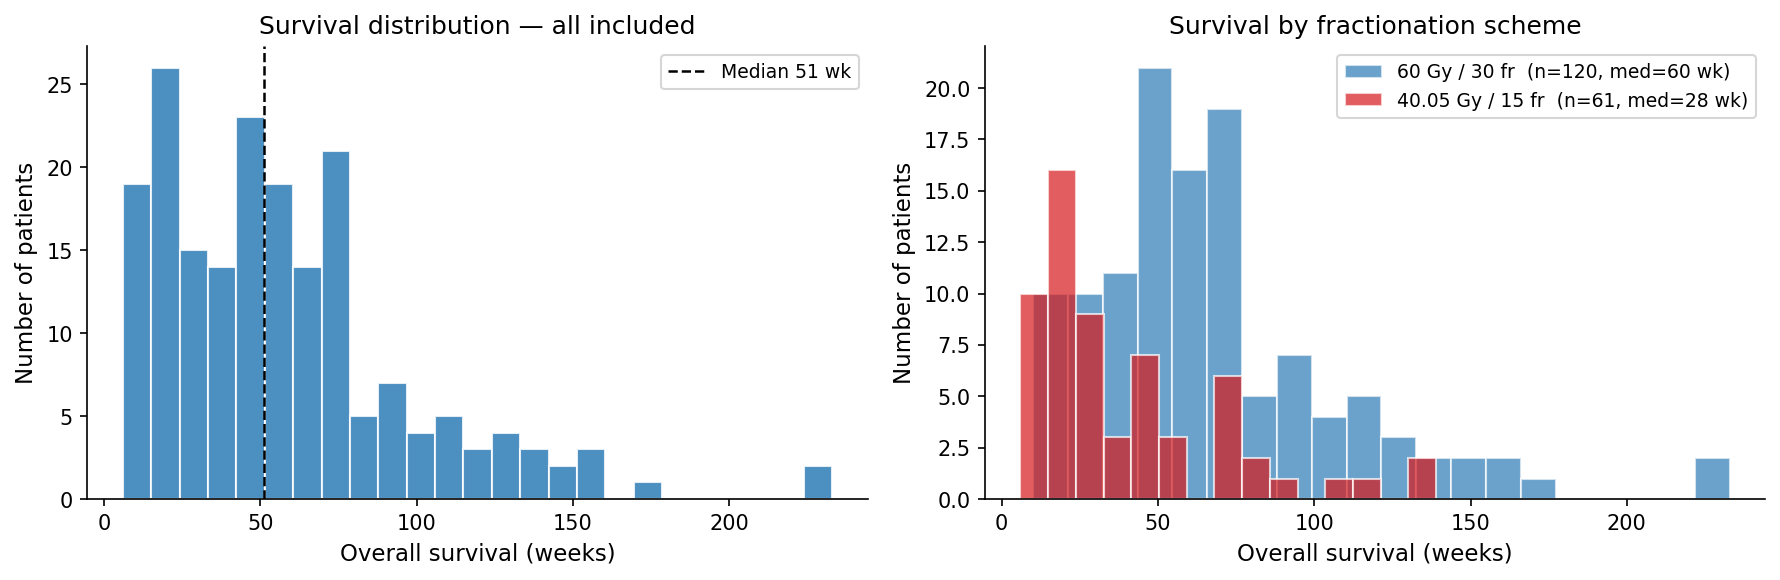

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival histogram — all included
ax = axes[0]
ax.hist(included["survival_weeks"].dropna(), bins=25, color=COLORS[0], alpha=0.85, edgecolor="white")
ax.axvline(included["survival_weeks"].median(), color="black", linestyle="--", linewidth=1.2,
           label=f"Median {included['survival_weeks'].median():.0f} wk")
ax.set_xlabel("Overall survival (weeks)")
ax.set_ylabel("Number of patients")
ax.set_title("Survival distribution — all included")
ax.legend(fontsize=9)

# Survival by fractionation scheme
ax = axes[1]
standard = included[included["rt_dose_gy"] == 60.0]["survival_weeks"].dropna()
hypo = included[included["rt_dose_gy"] == 40.05]["survival_weeks"].dropna()

ax.hist(standard, bins=20, alpha=0.7, color=COLORS[0], edgecolor="white",
        label=f"60 Gy / 30 fr  (n={len(standard)}, med={standard.median():.0f} wk)")
ax.hist(hypo, bins=15, alpha=0.7, color=COLORS[1], edgecolor="white",
        label=f"40.05 Gy / 15 fr  (n={len(hypo)}, med={hypo.median():.0f} wk)")
ax.set_xlabel("Overall survival (weeks)")
ax.set_ylabel("Number of patients")
ax.set_title("Survival by fractionation scheme")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_survival.png")
plt.show()

## 5. Summary Table

In [11]:
summary = pd.DataFrame({
    "Variable": [
        "Total patients", "Included", "Excluded",
        "Age — median (IQR)",
        "Sex — Female / Male",
        "WHO PS 0 / 1 / 2 / 3",
        "60 Gy / 30 fr (standard Stupp)",
        "40.05 Gy / 15 fr (hypofractionated)",
        "Other fractionation schemes",
        "EQD2 — median (IQR)",
        "Overall survival — median (IQR)",
        "Missing survival data",
    ],
    "Value": [
        len(cohort), len(included), len(excluded),
        f"{included['age'].median():.0f} ({included['age'].quantile(0.25):.0f}–{included['age'].quantile(0.75):.0f}) yr",
        f"{(included['sex']=='F').sum()} / {(included['sex']=='M').sum()}",
        " / ".join(str(included['who_status'].value_counts().sort_index().get(i, 0)) for i in range(4)),
        f"{(included['rt_dose_gy']==60.0).sum()}",
        f"{(included['rt_dose_gy']==40.05).sum()}",
        f"{((included['rt_dose_gy']!=60.0)&(included['rt_dose_gy']!=40.05)).sum()}",
        f"{included['eqd2_gy'].median():.1f} ({included['eqd2_gy'].quantile(0.25):.1f}–{included['eqd2_gy'].quantile(0.75):.1f}) Gy",
        f"{included['survival_weeks'].median():.0f} ({included['survival_weeks'].quantile(0.25):.0f}–{included['survival_weeks'].quantile(0.75):.0f}) wk",
        f"{included['survival_weeks'].isna().sum()}",
    ]
})

print(summary.to_string(index=False))
summary.to_csv(DATA_PROCESSED / "cohort_summary_table.csv", index=False)
print("\nSummary table saved to data/processed/cohort_summary_table.csv")

                           Variable               Value
                     Total patients                 264
                           Included                 190
                           Excluded                  74
                 Age — median (IQR)       70 (60–75) yr
                Sex — Female / Male            73 / 117
               WHO PS 0 / 1 / 2 / 3   34 / 101 / 47 / 8
     60 Gy / 30 fr (standard Stupp)                 120
40.05 Gy / 15 fr (hypofractionated)                  61
        Other fractionation schemes                   9
                EQD2 — median (IQR) 60.0 (42.3–60.0) Gy
    Overall survival — median (IQR)       51 (25–73) wk
              Missing survival data                   0

Summary table saved to data/processed/cohort_summary_table.csv
